**Problem Statement:** In today’s competitive market, businesses collect large volumes of customer data but often struggle to extract meaningful insights from it. Without proper analysis, companies fail to understand differences in customer spending behavior, preferences, and value. This lack of segmentation leads to generic marketing strategies, resulting in lower customer engagement, reduced satisfaction, and missed revenue opportunities. Therefore, there is a need to apply data-driven techniques to identify distinct customer groups based on their purchasing patterns.

**Objective:** The objective of this task is to use unsupervised learning techniques, such as clustering, to segment customers based on their spending habits and behavioral patterns. By identifying distinct customer groups, the goal is to enable businesses to design targeted and personalized marketing strategies for each segment, improve customer experience, and maximize profitability.

**Dataset Loading:** The dataset is typically loaded using Python libraries such as Pandas, which makes it easy to read and manipulate data.

Steps involved in loading the dataset:

**1. Import required libraries:** Pandas is used for handling data, while libraries like NumPy and Matplotlib are used for analysis and visualization.

**2. Load the dataset file:** The dataset (usually in CSV format) is loaded into a DataFrame using Pandas.

**3. Display the data:** The first few rows are viewed to understand the structure and contents of the dataset.

**4. Check dataset information:** Functions like .info() and .describe() are used to inspect data types, missing values, and basic statistics.

In [1]:
#Import required libraries
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()

#Load the dataset
data = pd.read_csv("Mall_Customers.csv")

#Display first 5 rows
print(data.head())

#Check dataset information
print(data.info())

#Summary statistics
print(data.describe())

Saving Mall_Customers.csv to Mall_Customers.csv
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
   

**Dataset Description:** The dataset used for customer segmentation typically contains information about customers’ demographic details and their spending behavior. It helps in identifying patterns and grouping customers with similar characteristics.

Common features in the dataset may include:

**1. Customer ID –** A unique identifier for each customer

**2. Gender –** Male or Female

**3. Age –** Age of the customer

**4. Annual Income –** Yearly income of the customer (usually in thousands)

**5. Spending Score –** A score assigned based on customer purchasing behavior (e.g., 1–100)

This dataset is suitable for unsupervised learning because it does not contain predefined labels. Instead, we aim to discover hidden patterns and group customers into clusters based on similarities in their income and spending habits.

**Data Cleaning and Preprocessing:** Before applying any clustering algorithm, it is important to clean and prepare the dataset so that the model can produce accurate and meaningful results.

**1. Handling Missing Values:** Datasets may contain missing or null values. These can affect clustering results, so we either: remove rows with missing values, or fill them using appropriate methods (mean, median, or mode)

**2. Removing Duplicates:** Duplicate records can bias the analysis. These are identified and removed to ensure each customer is represented only once.

**3. Selecting Relevant Features:** Not all columns are useful for clustering. For example: Customer ID is not useful for grouping. Features like Annual Income and Spending Score are more relevant.

**4. Encoding Categorical Variables:** If the dataset contains categorical data (e.g., Gender), it must be converted into numerical form using techniques like label encoding.

**5. Feature Scaling:** Clustering algorithms like K-Means are sensitive to scale. Features such as income and spending score may have different ranges, so we standardize them using scaling techniques.

In [2]:
#Import necessary libraries for preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

#Check for Missing Values
print("\nMissing values in each column:")
print(data.isnull().sum())

#If missing values exist, handle them
#Example: filling missing numerical values with mean
data.fillna(data.mean(numeric_only=True), inplace=True)


Missing values in each column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [3]:
#Remove Duplicate Rows
print("\nNumber of duplicate rows:", data.duplicated().sum())

#Drop duplicates if any
data.drop_duplicates(inplace=True)


Number of duplicate rows: 0


In [4]:
#Drop Unnecessary Columns
# CustomerID is not useful for clustering
if 'CustomerID' in data.columns:
    data.drop('CustomerID', axis=1, inplace=True)

In [5]:
#Encode Categorical Variables
# Convert 'Gender' into numerical values (Male=1, Female=0)
if 'Gender' in data.columns:
    encoder = LabelEncoder()
    data['Gender'] = encoder.fit_transform(data['Gender'])


In [6]:
#Select Features for Clustering
#Usually Annual Income and Spending Score are used
features = data[['Annual Income (k$)', 'Spending Score (1-100)']]

print("\nSelected features:")
print(features.head())


Selected features:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [7]:
#Feature Scaling
#Standardize the data so all features are on same scale
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#Convert back to DataFrame for better readability
scaled_data = pd.DataFrame(scaled_features, columns=features.columns)

print("\nScaled data sample:")
print(scaled_data.head())

#Final Output
print("\nData preprocessing completed successfully!")


Scaled data sample:
   Annual Income (k$)  Spending Score (1-100)
0           -1.738999               -0.434801
1           -1.738999                1.195704
2           -1.700830               -1.715913
3           -1.700830                1.040418
4           -1.662660               -0.395980

Data preprocessing completed successfully!


**Exploratory Data Analysis:** Exploratory Data Analysis (EDA) is the process of analyzing and visualizing the dataset to understand its structure, patterns, and relationships before applying machine learning models.

In customer segmentation, EDA helps to:

Understand how customers are distributed (age, income, spending)

Identify trends and patterns in spending behavior

Detect outliers or unusual values

Discover relationships between variables (e.g., income vs spending)

**Histograms** are used to understand the distribution of numerical variables such as age, annual income, and spending score. They show how frequently different values occur within specific ranges, helping us see whether the data is evenly distributed or skewed toward certain values. In this customer segmentation project, histograms help identify common income levels or spending behaviors among customers, which gives an initial idea of how customers are spread across different ranges.

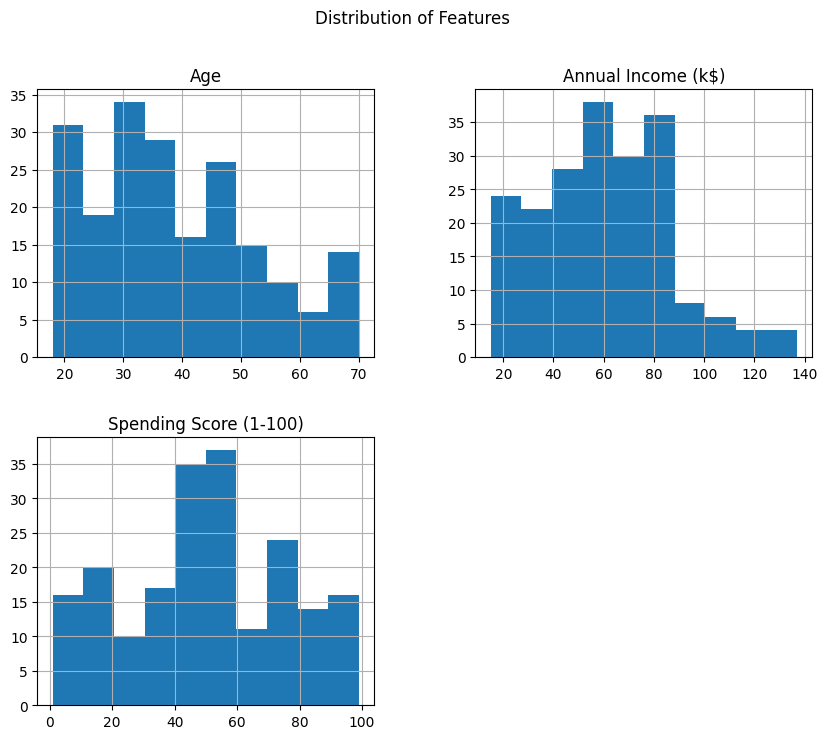

In [8]:
#Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

#Plot Histograms for numerical columns
data.hist(figsize=(10, 8))

plt.suptitle("Distribution of Features")
plt.show()

**Scatter Plots** are used to visualize the relationship between two numerical variables, such as annual income and spending score or age and spending score. By plotting data points on a graph, we can easily observe patterns, trends, or natural groupings within the data. In this context, scatter plots help us understand whether customers with higher income tend to spend more or whether different clusters of customers exist based on their spending behavior. These visual patterns are very useful for identifying potential customer segments.

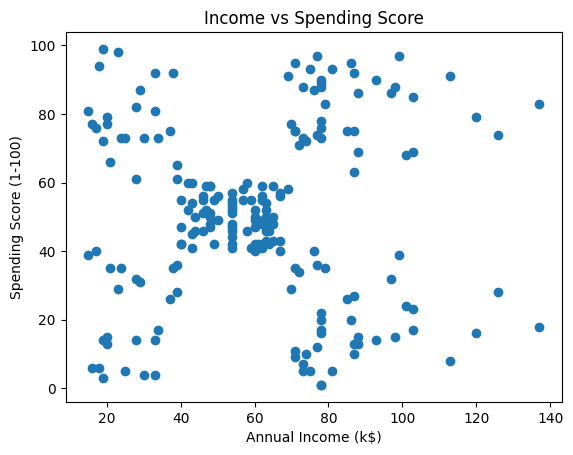

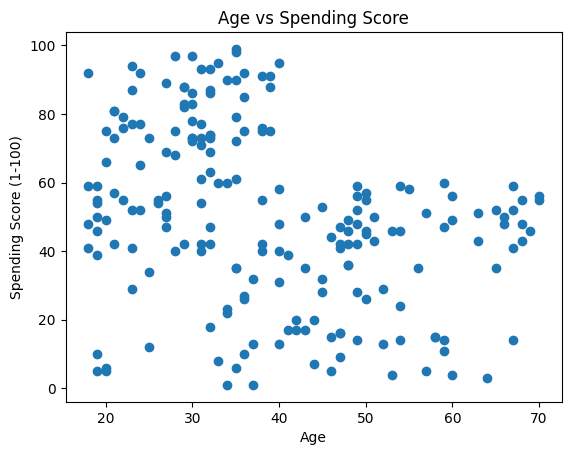

In [9]:
#Scatter Plot (Relationships)

#Income vs Spending Score
plt.figure()
plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Income vs Spending Score")

plt.show()

#Age vs Spending Score
plt.figure()
plt.scatter(data['Age'], data['Spending Score (1-100)'])

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending Score")

plt.show()

**Correlation Matrix** is used to measure and display the strength of relationships between different variables in the dataset. It shows whether variables are positively related, negatively related, or not related at all. In this project, it helps us understand how features like age, income, and spending score influence each other. For example, if spending score has a weak correlation with age but a stronger relationship with income, it suggests that income is a more important factor for customer segmentation.


Correlation Matrix:
                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


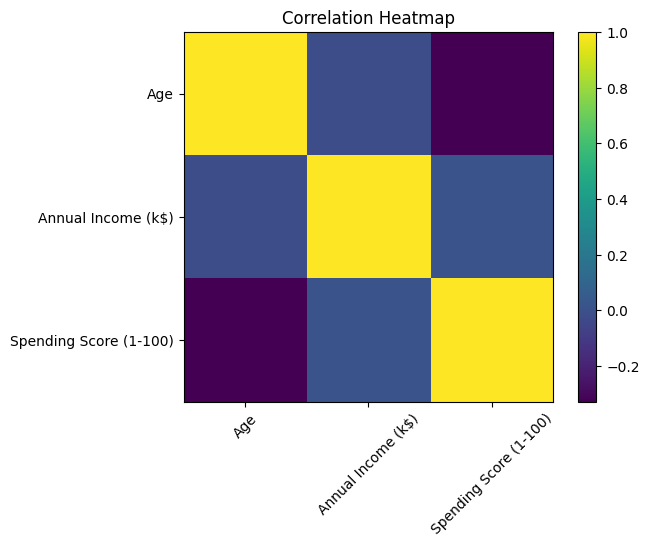

In [10]:
#Correlation Matrix
correlation = data.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation)

#Visualize correlation using heatmap
plt.figure()
plt.imshow(correlation)

plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")
plt.show()

**Box Plots** are used to identify the spread of the data and detect outliers, which are extreme values that differ significantly from other observations. They display the median, quartiles, and any unusual data points outside the normal range. In this customer dataset, box plots help us detect customers with unusually high income or spending scores. These outliers are important because they can influence clustering results and may represent special customer groups, such as luxury or premium customers.

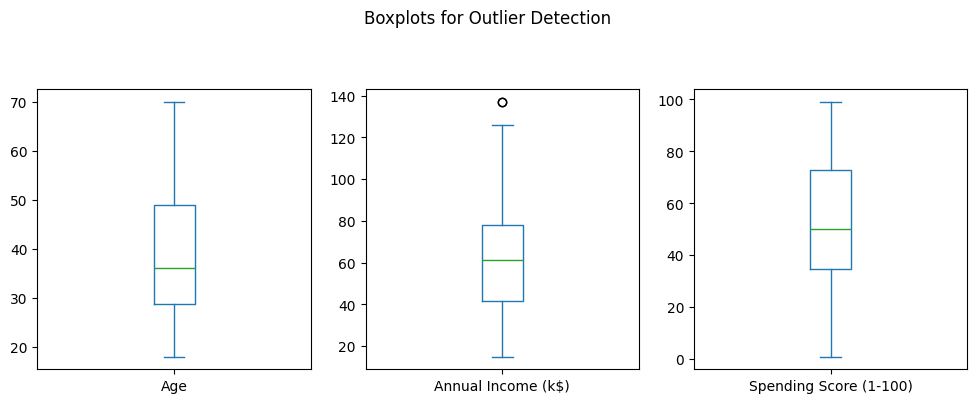


Exploratory Data Analysis completed successfully!


In [11]:
#Boxplots (Outlier Detection)

#Boxplot for numerical features
data.plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 8))

plt.suptitle("Boxplots for Outlier Detection")
plt.show()

#Final Message
print("\nExploratory Data Analysis completed successfully!")

**Model Building** is the stage where we apply the **K-Means Clustering** algorithm to group customers based on similar spending behavior. Since this is an unsupervised learning method, it does not require labeled data and instead finds hidden patterns in the dataset.

First, important features like annual income and spending score are selected and scaled so that all values are on the same range. Then, the K-Means algorithm is applied by choosing the number of clusters (K). To find the best value of K, the Elbow Method is used, which helps identify the optimal number of customer groups.

After selecting the best K, the model assigns each customer to a cluster based on similarity. Finally, the clusters are visualized to understand different customer segments for better marketing strategies.

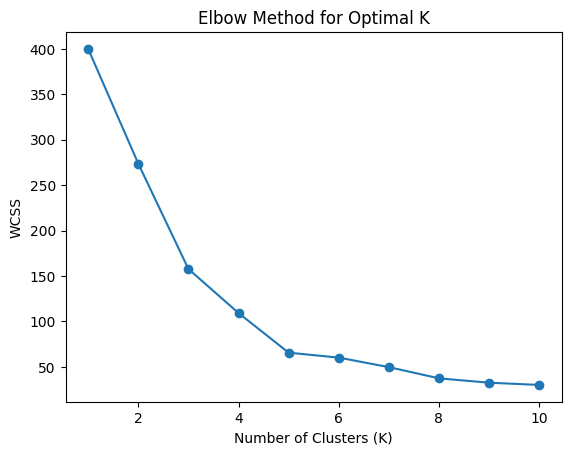

In [12]:
#Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

#K-Means model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Select features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]


#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method to find optimal K

wcss = []

#Try different cluster numbers (1 to 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

#Plot Elbow Curve
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

**Elbow Method** is used to determine the optimal number of clusters (K) in K-Means clustering by analyzing the **Within-Cluster Sum of Squares (WCSS)**, which measures how closely the data points in each cluster are grouped around their centroid. In this method, different values of K are tested, and for each value, WCSS is calculated. These results are then plotted on a graph where the **x-axis represents the number of clusters (K)** and the **y-axis represents the WCSS value**. As K increases, WCSS decreases because clusters become smaller and more specific. However, after a certain point, the decrease in WCSS slows down significantly, forming a bend or “elbow” shape on the graph. This point is considered the optimal number of clusters because it provides a good balance between accuracy and simplicity in clustering.

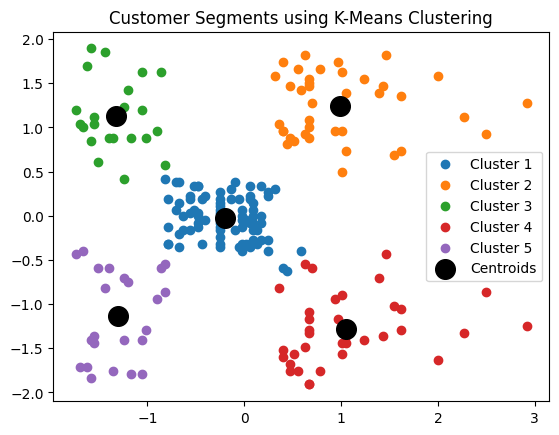

K-Means clustering completed successfully!
    Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0    Male   19                  15                      39        4
1    Male   21                  15                      81        2
2  Female   20                  16                       6        4
3  Female   23                  16                      77        2
4  Female   31                  17                      40        4


In [16]:
#Apply K-Means with optimal K (e.g., 5)

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

#Add cluster labels to original data
data['Cluster'] = y_kmeans


#Visualize Clusters
plt.figure()

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], label='Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], label='Cluster 4')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], label='Cluster 5')

#Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')

plt.title("Customer Segments using K-Means Clustering")
plt.legend()
plt.show()

#Final Output
print("K-Means clustering completed successfully!")
print(data.head())

K-Means clustering is an unsupervised machine learning algorithm used to divide customers into different groups based on similarities in their behavior, such as income and spending habits. In customer segmentation, it automatically groups customers into clusters without any predefined labels. Each cluster represents a segment of customers with similar characteristics. The algorithm works by assigning each customer to the nearest cluster center (centroid) and continuously updating these centers until stable groups are formed. This helps businesses understand different types of customers and design targeted marketing strategies for each group.

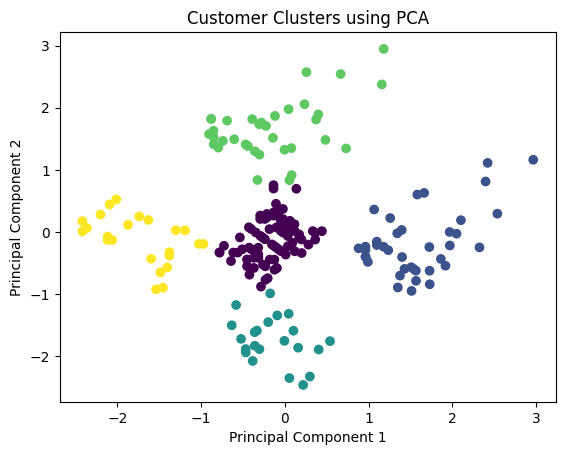

In [15]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Apply PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Visualize clusters
plt.figure()

# Use 'y_kmeans' which contains the cluster labels from the previous K-Means step
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')

plt.title("Customer Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

**PCA (Principal Component Analysis)** is a dimensionality reduction technique used to simplify complex datasets by converting them into two main components while preserving most of the important information. In customer segmentation, PCA helps in visualizing clusters in 2D space when the dataset has multiple features. After applying PCA, each customer is plotted based on two principal components, making it easier to see how K-Means has grouped similar customers together. This helps in clearly understanding whether the clusters are well separated or overlapping, which is useful for evaluating the performance of the clustering model.

**Model Evaluation** in K-Means clustering is used to assess how well the algorithm has grouped customers into meaningful segments. Since it is an unsupervised learning method, traditional accuracy metrics are not used. Instead, evaluation is done using methods like the Elbow Method, which helps in selecting the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS). A lower WCSS value indicates that data points are closer to their cluster centroids, meaning better-defined clusters. Additionally, visualization techniques such as PCA or t-SNE are used to check how well the clusters are separated in a reduced 2D space. If clusters appear clearly distinct and well-organized, it indicates that the model has performed effectively in identifying customer segments.

**1. High Income – High Spending (VIP Customers)**: These are premium customers who earn well and also spend a lot.

**Marketing Strategies:**

a) Offer exclusive VIP memberships and loyalty programs

b) Provide personalized recommendations and premium products

c) Early access to sales and new collections

d) High-end customer service and priority support

**Goal:** Retain and reward high-value customers

**2. High Income – Low Spending (Careful / Potential Customers)**: These customers have good income but spend less.

**Marketing Strategies:**

a) Offer targeted discounts on luxury items

b) Use personalized ads to increase interest in premium products

c) Send product bundles or limited-time offers

d) Highlight product value and quality

**Goal:** Increase spending behavior

**3. Low Income – High Spending (Impulsive / Budget Spenders)**:
These customers spend more despite lower income.

**Marketing Strategies:**

a) Offer affordable deals and discount campaigns

b) Introduce installment/payment plans

c) Promote budget-friendly product lines

d) Use flash sales and seasonal offers

**Goal:** Encourage frequent but controlled spending

**4. Low Income – Low Spending (Inactive / Budget-Sensitive Customers):** These customers spend less and have limited income.

**Marketing Strategies:**

a) Focus on awareness campaigns and engagement

b) Provide heavy discounts or low-cost products

c) Use social media marketing and promotions

d) Improve customer onboarding experience

**Goal:** Increase engagement and first-time purchases

**5. Average Income – Average Spending (Standard Customers):** These are balanced customers with moderate behavior.

**Marketing Strategies:**

a) Offer general promotions and seasonal sales

b) Encourage loyalty program participation

c) Recommend mid-range products

d) Cross-selling and upselling strategies

**Goal:** Gradually increase engagement and spending

**Final Conclusion with Insights:** In this project, K-Means clustering was used to segment customers based on their income and spending behavior. The Elbow Method helped determine the optimal number of clusters, and the results were visualized to understand different customer groups.

The analysis revealed clear customer segments such as high-value customers (high income, high spending), potential customers (high income, low spending), budget or impulsive customers (low income, high spending), and low-engagement customers (low income, low spending). These insights help businesses create targeted marketing strategies, improve customer engagement, and increase overall profitability through better decision-making.